In [1]:
import json
from pathlib import Path
import re, pickle
import math
import numpy as np

In [2]:
# filename = 'PSA_OpenBench_Alpha.json'
# filename = 'PSA_OpenBench_Beta.json'
# filename = 'PSA_OpenBench_Gamma.json'
# filename = 'PSA_PrivateBench_4.json'
# filename = 'PSA_PrivateBench_2.json'
# filename = 'PSA_PrivateBench_3.json'
# filename = 'PSA_PrivateBench_1.json'
# data = json.loads(Path(filename).read_text())

In [2]:
def get_embedding(text):
    return model_sentence.encode(text)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [3]:
# load the results_summary from a pickle file
with open('FSI_R_results_summary_Claude 4.5 Haiku.pkl', 'rb') as f:
    results_summary = pickle.load(f)
results_summary

[{'idx': 6,
  'q_idx': 2,
  'Num_perturbed_generated': 5,
  'Sims_content': [0.8127650618553162,
   0.8379067182540894,
   0.8086117506027222,
   0.8387844562530518,
   0.78264319896698],
  'Sims_question': [0.6923112869262695,
   0.746978223323822,
   0.6908153295516968,
   0.631869912147522,
   0.7105985283851624],
  'Sims_solution': [0.6704102158546448,
   0.6313221454620361,
   0.7138555645942688,
   0.6808702349662781,
   0.7315652370452881],
  'Binary_Results': [0, 0, 0, 0, 0],
  'FLI_R': [0.893732197971579,
   0.797993248461715,
   0.9551230852811143,
   0.9352448469733078,
   0.9809773964233067],
  'mean_result': 0.0,
  'mean_FLI_R': 0.9126141550222047},
 {'idx': 14,
  'q_idx': 0,
  'Num_perturbed_generated': 5,
  'Sims_content': [0.6579881310462952,
   0.7212736010551453,
   0.7624252438545227,
   0.6412796378135681,
   0.6156201958656311],
  'Sims_question': [0.8744264245033264,
   0.8448421955108643,
   0.8744264245033264,
   0.7572266459465027,
   0.7572266459465027],
  'Si

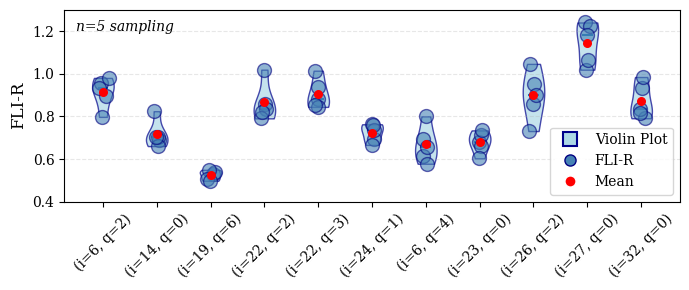

In [9]:
# Box plot with individual data points for FLI_R distributions
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'

# Extract FLI_R distributions and labels
fli_r_distributions = [entry['FLI_R'] for entry in results_summary]
labels = [f"(i={entry['idx']}, q={entry['q_idx']})" for entry in results_summary]
pair_numbers = list(range(1, len(results_summary) + 1))

# Create figure
fig, ax = plt.subplots(figsize=(7, 3))

# Prepare data for box plot
box_data = fli_r_distributions

# Create box plot
# use a violin‑style plot so each column looks more like a “drop”
vp = ax.violinplot(
    box_data,
    positions=pair_numbers,
    widths=0.4,
    showmedians=True,
    showextrema=False     # no whiskers/caps – keeps the drop silhouette
)
# colour the bodies
for body in vp['bodies']:
    body.set_facecolor('lightblue')
    body.set_edgecolor('darkblue')
    body.set_alpha(0.7)

# draw the medians explicitly if you want a bold red line/point
for pos, dat in zip(pair_numbers, box_data):
    ax.scatter(pos, np.mean(dat), color='red', s=30, zorder=4)

# Overlay individual data points with jitter
for i, (pair_num, values) in enumerate(zip(pair_numbers, box_data)):
    # Add jitter to x-positions
    jitter = np.random.normal(0, 0.04, len(values))
    x_positions = pair_num + jitter
    
    # Plot individual points
    ax.scatter(
        x_positions,
        values,
        alpha=0.6,
        s=100,
        color='steelblue',
        edgecolors='navy',
        linewidth=1,
        zorder=3
    )

# Axis setup
ax.set_ylabel('FLI-R', fontsize=12)
ax.set_xticks(pair_numbers)
ax.set_xticklabels(labels, rotation=45, ha='center', fontsize=10)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0.4, 1.3)

# add an annotation for  (n=5 sampling) to the top left corner
ax.text(0.02, 0.95, 'n=5 sampling', transform=ax.transAxes, fontsize=10, verticalalignment='top', fontstyle='italic')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lightblue', marker='s', linestyle='None', markersize=10, 
           markerfacecolor='lightblue', markeredgecolor='darkblue', markeredgewidth=1.5, label='Violin Plot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, 
           markeredgecolor='navy', markeredgewidth=1, label='FLI-R'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='Mean'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Adjust layout and show
plt.tight_layout()

# Save the plot as a PDF
plt.savefig('FLI_R_Claude_boxplot.pdf', format='pdf', bbox_inches='tight')
plt.show()

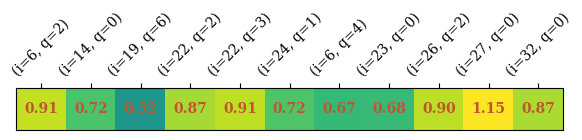

In [7]:
# single heatmap
import matplotlib.pyplot as plt

# Extract mean_FLI_R and labels
mean_FLI_R = [float(entry['mean_FLI_R']) for entry in results_summary]
labels = [f"(i={entry['idx']}, q={entry['q_idx']})" for entry in results_summary]

# Reshape into 1-row heatmap
slope_array = np.array(mean_FLI_R).reshape(1, -1)

# Plot
plt.figure(figsize=(6, 1.5))
plt.imshow(slope_array, cmap="viridis", aspect="auto", vmin=0, vmax=1)

# Annotate values on heatmap
for i, val in enumerate(mean_FLI_R):
    # plt.text(i, 0, f"{val:.2f}", ha='center', va='center', color='pink', fontsize=10)
    plt.text(i, 0, f"{val:.2f}", ha='center', va='center', color='#bf5631', fontsize=10, fontweight='heavy')

# Axis setup
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='center',fontsize=10)
plt.yticks([])

# Move x-axis labels to the top
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()

# Add colorbar
# plt.colorbar(label="Slope Value")

# Adjust layout and show
plt.tight_layout()

# Save the plot as a PDF
plt.savefig('FSI_R_Claude_heat.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [8]:
# Get the colormap to match with the lineplot
cmap = plt.get_cmap("viridis")

# Normalize the slope values to the range [0, 1] for the colormap
norm = plt.Normalize(vmin=min(mean_FLI_R), vmax=max(mean_FLI_R))

# Extract colors for indices 1, 7, and 9
colors = [cmap(norm(mean_FLI_R[i])) for i in range(len(mean_FLI_R))]

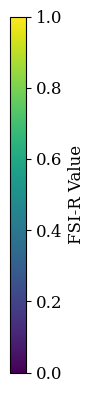

In [10]:
# Get the colorbar
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

# Define the range of values for the colorbar
vmin = min(mean_FLI_R)  # Minimum slope value
vmax = max(mean_FLI_R)  # Maximum slope value

# Create a figure for the colorbar
plt.figure(figsize=(1., 4))  # Adjust the size for the vertical colorbar

# Create a vertical colorbar
norm = Normalize(vmin=0, vmax=1)
cbar = ColorbarBase(plt.gca(), cmap="viridis", norm=norm, orientation="vertical")

# Add a label to the colorbar
cbar.set_label("FSI-R Value", fontsize=12)

# Show the colorbar
plt.tight_layout()
plt.yticks(fontsize=12)

# Save the plot as a PDF
plt.savefig('FSI_R_Claude_Colorbar.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

# Directory containing the .pkl files
pkl_dir = Path("./")  # Replace with the actual path
pkl_files = list(pkl_dir.glob("FSI_R*.pkl"))  # Get all .pkl files in the directory
pkl_files
pkl_files = [pkl_files[i] for i in [2,1,0,3]]

In [17]:

# Initialize lists to store slopes and labels
all_mean_FLI_R = []
row_labels = []

# Load each .pkl file and extract slopes
for pkl_file in pkl_files:
    with open(pkl_file, "rb") as f:
        results_summary = pickle.load(f)
    
    # Extract slopes for the current file
    mean_FLI_R = [float(entry['mean_FLI_R']) for entry in results_summary]
    all_mean_FLI_R.append(mean_FLI_R)
    
    # Create a label for the row (e.g., file name without "results_summary_")
    row_labels.append(pkl_file.stem.replace("FSI_R_results_summary_", ""))
# all_slopes

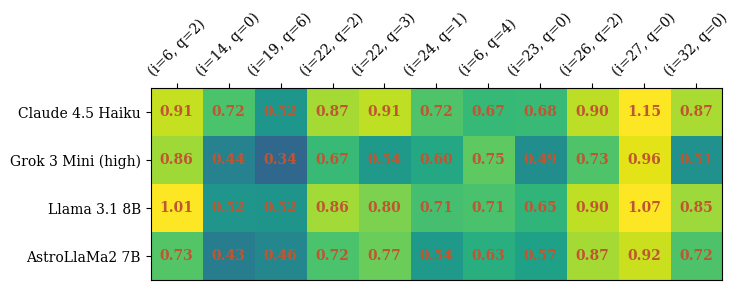

In [ ]:

# Convert to a 2D array for the heatmap
mean_FLI_R_matrix = np.array(all_mean_FLI_R)

# Create the heatmap
plt.figure(figsize=(7.5, 3))
plt.imshow(mean_FLI_R_matrix, cmap="viridis", aspect="auto", vmin=0, vmax=1)
# Annotate values on the heatmap
for i in range(mean_FLI_R_matrix.shape[0]):  # Rows
    for j in range(mean_FLI_R_matrix.shape[1]):  # Columns
        val = mean_FLI_R_matrix[i, j]
        # plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='#bf5631', fontsize=10, fontweight='heavy')

# Axis setup
column_labels = [f"(i={entry['idx']}, q={entry['q_idx']})" for entry in results_summary]
plt.xticks(ticks=np.arange(len(column_labels)), labels=column_labels, rotation=45, ha='center', fontsize=10)
plt.yticks(ticks=np.arange(len(row_labels)), labels=row_labels, fontsize=10)

# Add colorbar
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()

# Adjust layout and show
plt.tight_layout()
plt.savefig('FSI_R_multirow_heatmap_nonumber.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [12]:
# show colorbar limits
vmin = mean_FLI_R_matrix.min()
vmax = mean_FLI_R_matrix.max()
print(f"Min: {vmin}\n")
print(f"Max: {vmax}\n")

Min: 0.33923692753905055

Max: 1.1467805583202857

